<a href="https://colab.research.google.com/github/Phalguni-dhabale/MV-LAB/blob/main/PRACTICAL_3_MV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [27]:
uploaded = files.upload()

Saving test_stop.jpg to test_stop.jpg
Saving stop_sign.jpg to stop_sign (1).jpg


In [28]:
img1 = cv2.imread("stop_sign.jpg")
img2 = cv2.imread("test_stop.jpg")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

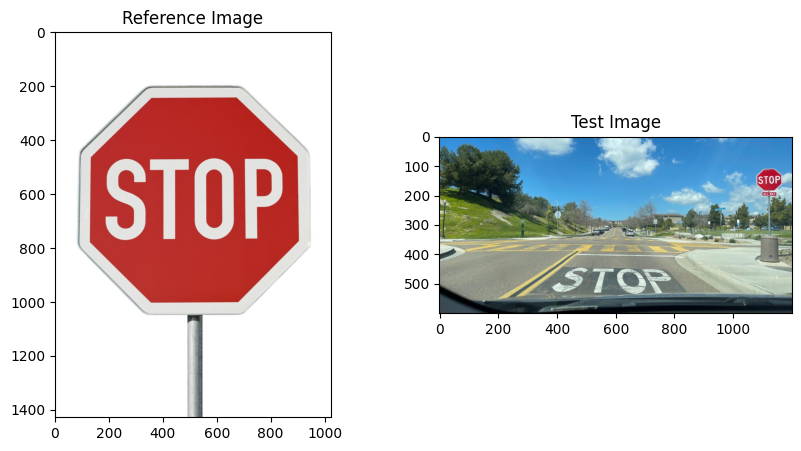

In [29]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Reference Image")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Test Image")

plt.show()

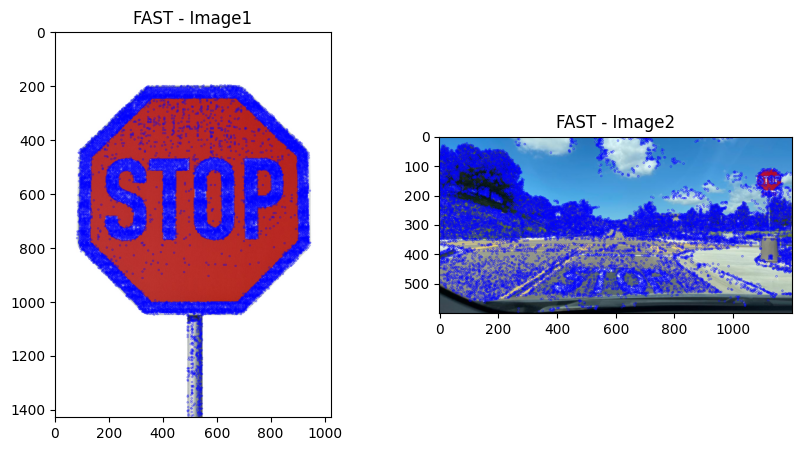

In [30]:
fast = cv2.FastFeatureDetector_create()

kp1 = fast.detect(gray1, None)
kp2 = fast.detect(gray2, None)

img_fast1 = cv2.drawKeypoints(img1, kp1, None, color=(255,0,0))
img_fast2 = cv2.drawKeypoints(img2, kp2, None, color=(255,0,0))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_fast1, cv2.COLOR_BGR2RGB))
plt.title("FAST - Image1")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_fast2, cv2.COLOR_BGR2RGB))
plt.title("FAST - Image2")

plt.show()

In [31]:
orb = cv2.ORB_create(nfeatures=1000)

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

print("Features in Image1:", len(kp1))
print("Features in Image2:", len(kp2))

Features in Image1: 923
Features in Image2: 1000


In [32]:
if des1 is None or des2 is None:
    print("Descriptors not found.")
else:
    print("Descriptors extracted successfully.")

Descriptors extracted successfully.


In [33]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

print("Total Matches:", len(matches))

Total Matches: 122


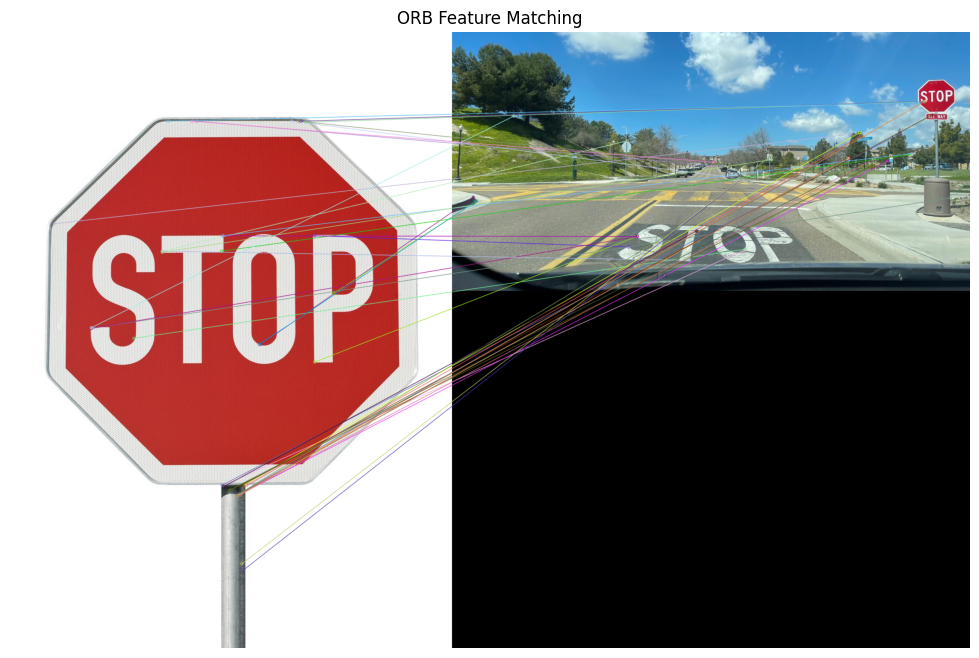

In [34]:
matched = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    matches[:40],
    None,
    flags=2
)

plt.figure(figsize=(18,8))
plt.imshow(cv2.cvtColor(matched, cv2.COLOR_BGR2RGB))
plt.title("ORB Feature Matching")
plt.axis("off")
plt.show()

In [35]:
good_matches = [m for m in matches if m.distance < 50]

matching_percentage = (len(good_matches) / min(len(kp1), len(kp2))) * 100

print("Good Matches:", len(good_matches))
print("Matching Percentage:", round(matching_percentage,2), "%")

Good Matches: 14
Matching Percentage: 1.52 %


In [36]:
if matching_percentage > 20:
    print("Road Sign Identified Successfully")
else:
    print("Road Sign Not Identified")

Road Sign Not Identified


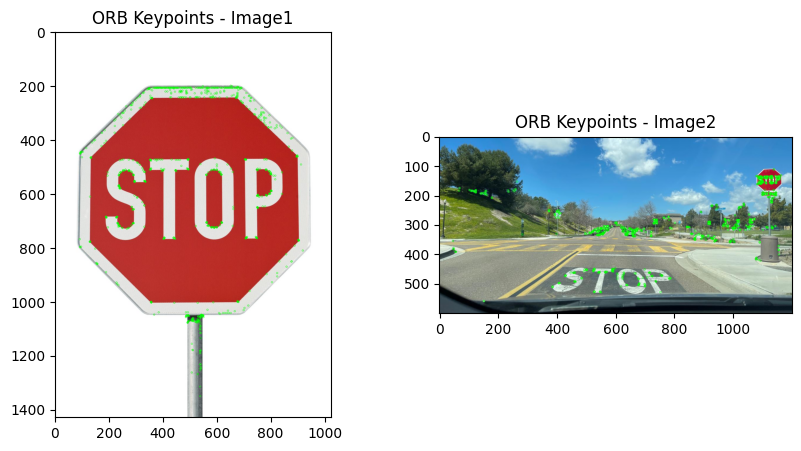

In [37]:
orb1 = cv2.drawKeypoints(img1, kp1, None, color=(0,255,0))
orb2 = cv2.drawKeypoints(img2, kp2, None, color=(0,255,0))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(orb1, cv2.COLOR_BGR2RGB))
plt.title("ORB Keypoints - Image1")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(orb2, cv2.COLOR_BGR2RGB))
plt.title("ORB Keypoints - Image2")

plt.show()